In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('MSUstyle')
try:
    from sarkas.potentials import list_potentials, get_potential, list_potential_aliases
    print('Available potentials:', list_potentials())
    print('Available aliases:', list_potential_aliases())
    
    # Test getting each potential
    for pot_name in list_potentials():
        try:
            pot_class = get_potential(pot_name)
            print(f'{pot_name}: {pot_class.__name__} - OK')
        except Exception as e:
            print(f'{pot_name}: ERROR - {e}')
            
except Exception as e:
    print(f'Import error: {e}')

Available potentials: ['yukawa', 'coulomb', 'qsp', 'mie', 'egs', 'yukawa_ft']
Available aliases: {'screened_coulomb': 'yukawa', 'debye_huckel': 'yukawa', 'coulombic': 'coulomb', 'quantumstatisticalpotential': 'qsp', 'deutsch': 'qsp', 'kelbg': 'qsp', 'hansen': 'qsp', 'miepotential': 'mie', 'lj': 'mie', 'lennard_jones': 'mie', 'exactgradientscreened': 'egs', 'yukawafriedeltail': 'yukawa_ft', 'yft': 'yukawa_ft'}
yukawa: Yukawa - OK
coulomb: Coulomb - OK
qsp: QuantumStatisticalPotential - OK
mie: MiePotential - OK
egs: ExactGradientScreened - OK
yukawa_ft: YukawaFriedelTail - OK


In [2]:
# from sarkas.potentials import Coulomb

# pot = Coulomb(testing_mode=True)
# pot.validate_setup()

from sarkas.potentials import Coulomb, YukawaFriedelTail

pot = YukawaFriedelTail(testing_mode=True)
pot.validate_setup()

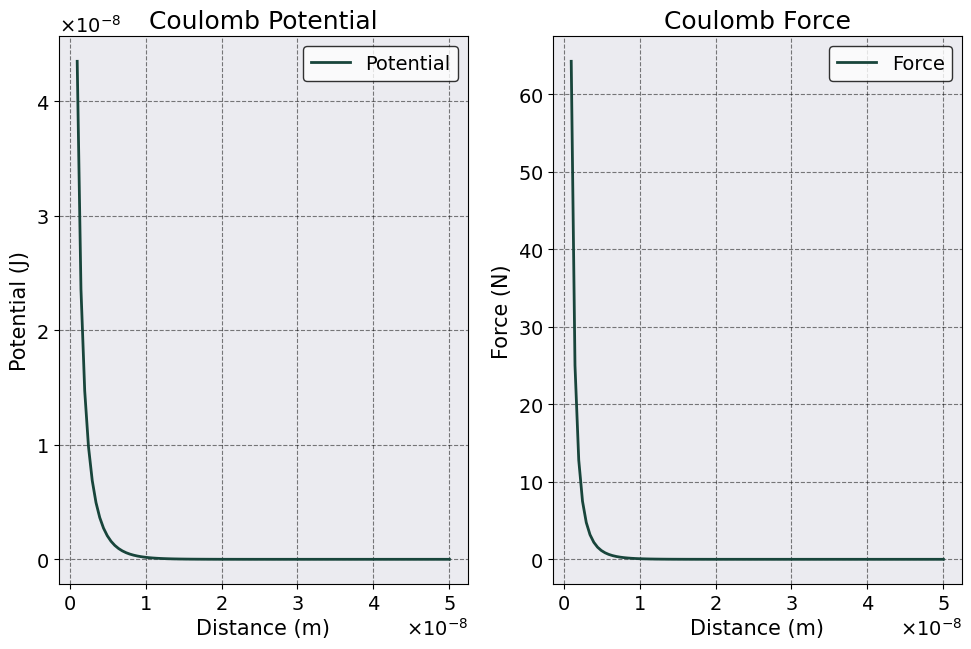

In [6]:
r = np.linspace(0.1, 5, 100) * 1e-8  # Distance in meters

fig, ax = plt.subplots( 1,2)
ax[0].plot(r, pot.potential_derivatives(r, pot.matrix[0,0])[0], label='Potential')
ax[1].plot(r, -pot.potential_derivatives(r, pot.matrix[0,0])[1], label='Force')
# ax[0].set_yscale("symlog", linthresh=1e-20)
# ax[1].set_yscale("symlog", linthresh=1e-20)
for a in ax:
    a.grid(True, alpha = 0.5)
ax[0].set_title('Coulomb Potential')
ax[1].set_title('Coulomb Force')
ax[0].set_xlabel('Distance (m)')
ax[1].set_xlabel('Distance (m)')
ax[0].set_ylabel('Potential (J)')
ax[1].set_ylabel('Force (N)')
ax[0].legend()
ax[1].legend()
plt.tight_layout()